<a href="https://colab.research.google.com/github/fadlizaenalaripin/machine-learning/blob/main/clustering_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# mengupload file csv dari lokal
from google.colab import files
uploaded = files.upload()

# membaca file csv nya
df = pd.read_csv('data_pelanggan_clustering.csv')

# tampilkan 5 baris pertama
df.head()

Saving data_pelanggan_clustering.csv to data_pelanggan_clustering (1).csv


,ID,Nama,Umur,Jenis Kelamin,Penghasilan (juta/tahun),Skor Pengeluaran
0,1,Pelanggan_1,58,Laki-laki,26,95
1,2,Pelanggan_2,35,Laki-laki,77,18
2,3,Pelanggan_3,65,Laki-laki,193,95
3,4,Pelanggan_4,52,Laki-laki,171,55
4,5,Pelanggan_5,20,Laki-laki,43,28


In [ ]:
# mengecek nama-nama kolom pada dataset
print(df.columns)

Index(['ID', 'Nama', 'Umur', 'Jenis Kelamin', 'Penghasilan (juta/tahun)',
       'Skor Pengeluaran'],
      dtype='object')


In [ ]:
# mengambil kolom numerik untuk clustering
fitur = df[['Umur', 'Penghasilan (juta/tahun)', 'Skor Pengeluaran']]

In [ ]:
from sklearn.preprocessing import StandardScaler

# membuat object scaler
scaler = StandardScaler()

# fit dan trasnform fitur numerik
fitur_scaled = scaler.fit_transform(fitur)

print(fitur_scaled[:5])

[[ 1.07181103 -1.42414175  1.49561825]
 [-0.57823272 -0.5718626  -1.18258187]
 [ 1.57399825  1.36665469  1.49561825]
 [ 0.64136483  0.99900486  0.10434546]
 [-1.65434821 -1.1400487  -0.83476367]]


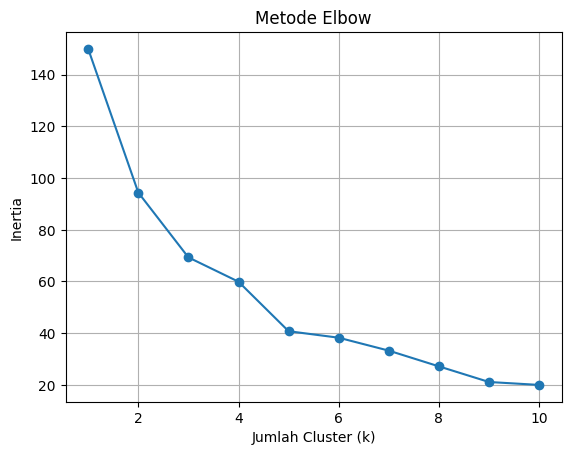

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# daftar untuk menyimpan nilai inertia
inertia = []

# coba jumlah cluster dari 1 sampai 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(fitur_scaled)
    inertia.append(kmeans.inertia_)

# visualisasikan hasil elbow
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Metode Elbow')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [ ]:
df['Cluster'] = kmeans.labels_

# Cek jumlah anggota tiap cluster
df['Cluster'].value_counts()

# Lihat karakteristik dari masing-masing cluster
df.groupby('Cluster')[['Umur', 'Penghasilan (juta/tahun)', 'Skor Pengeluaran']].mean()

,Umur,Penghasilan (juta/tahun),Skor Pengeluaran
Cluster,,,
0,41.000000,187.666667,34.666667
1,58.000000,78.166667,63.333333
2,25.125000,69.250000,28.250000
3,55.833333,172.500000,90.500000
4,51.750000,29.750000,95.250000
5,56.000000,182.600000,56.000000
6,42.200000,45.400000,38.400000
7,49.500000,131.250000,10.750000
8,25.000000,54.333333,79.333333


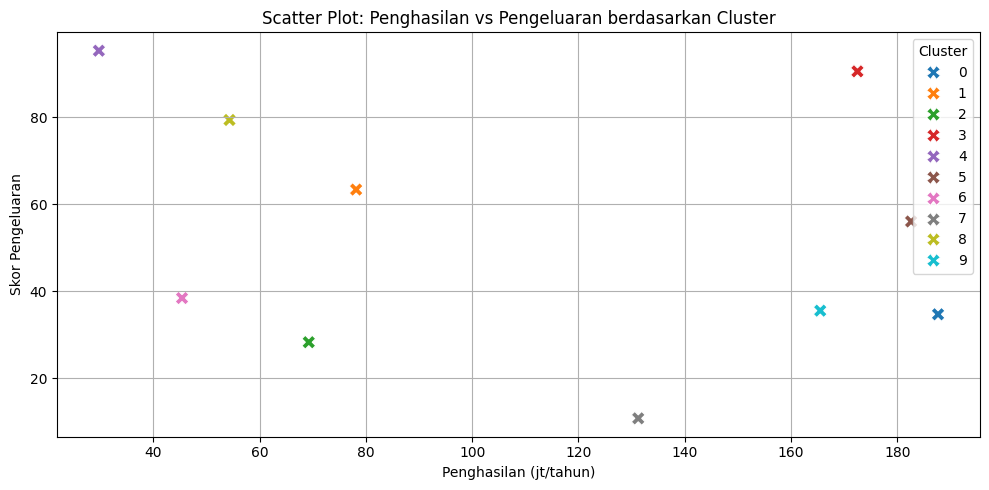

In [ ]:
# Scatter plot berdasarkan cluster dengan marker 'X'
plt.figure(figsize=(10, 5))
scatter = sns.scatterplot(
    data=df,
    x='Penghasilan',
    y='Pengeluaran',
    hue='Cluster',
    palette='tab10',
    s=100,
    marker='X'
)
plt.title("Scatter Plot: Penghasilan vs Pengeluaran berdasarkan Cluster")
plt.xlabel("Penghasilan (jt/tahun)")
plt.ylabel("Skor Pengeluaran")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()